# Overdamped Langevin Inference (OLI) — Acoustic Force Field Recovery

This notebook applies the **Overdamped Langevin Inference** algorithm to synthetic cell trajectory data generated by k-Wave acoustic simulations. It is the overdamped counterpart of `underdampedSFI.ipynb`.

## Physics

The overdamped Langevin SDE describes a particle whose inertia is negligible relative to viscous drag:

$$dx/dt = F(x) + \sqrt{2D}\, \xi(t)$$

where
- $F(x)$ is the Ito drift (acoustic radiation force / $\gamma$, units m/s)
- $D = k_BT / \gamma$ is the scalar diffusion coefficient
- $\xi(t)$ is Gaussian white noise

This regime is appropriate when the viscous relaxation time $m/\gamma$ is much shorter than the observation timestep $\Delta t$. For micron-scale cells in aqueous medium this is typically well satisfied.

## How it differs from ULI

| | Underdamped (ULI) | Overdamped (OLI) |
|---|---|---|
| State | $(x, v)$ — position + velocity | $x$ — position only |
| Inferred | $F(x,v) = F_{\rm acoustic}(x) - \gamma v$ | $F(x) = F_{\rm acoustic}(x)/\gamma$ |
| Basis | polynomial in $x$ + Fourier + linear in $v$ | polynomial in $x$ + Fourier (no $v$) |
| $\gamma$ recovery | explicit (velocity coefficient) | absorbed into $D$ |
| SFI class | `UnderdampedLangevinInference` | `OverdampedLangevinInference` |

## Pipeline

1. Load synthetic trajectory data
2. Visualise trajectories
3. OLI force inference with normalised basis
4. Inspect inferred coefficients
5. Validate against k-Wave ground-truth force map
6. Sweep all transducer configurations

In [13]:
import os
import sys
import json
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter

# SFI package (must be on path)
sys.path.insert(0, 'StochasticForceInference')
os.environ["JAX_PLATFORMS"] = "cpu"

import jax.numpy as jnp
from jax import random, jit
from jax import vmap
import SFI

print("SFI version:", SFI.__version__)
print("Imports OK")

SFI version: 0+unknown
Imports OK


## 1. Load trajectory data

The trajectory CSVs are the same as for ULI. The only difference is that `StochasticTrajectoryData` does **not** need `compute_dXplus=True` — the overdamped inference requires only first-order increments $\Delta X = X(t+\Delta t) - X(t)$.

In [14]:
# Load trajectory metadata
with open('trajectoryData/traj_metadata.json') as f:
    traj_meta = json.load(f)

print(f"Total acoustic field simulations: {len(traj_meta)}")
print(f"Cells per field: {traj_meta[0]['n_cells']}")
print(f"Steps per trajectory: {traj_meta[0]['n_steps']}  ×  dt={traj_meta[0]['dt']} s")
print(f"Total duration: {traj_meta[0]['n_steps'] * traj_meta[0]['dt']:.0f} s")

Total acoustic field simulations: 20
Cells per field: 48
Steps per trajectory: 5000  ×  dt=0.01 s
Total duration: 50 s


In [15]:
def load_trajectories(sim_entry: dict):
    """
    Load the multi-particle trajectory CSV for one acoustic field.
    For overdamped inference we do NOT request compute_dXplus — only
    first-order increments dX are needed.

    Returns (data, dt)
    """
    metadata, particle_indices, time_indices, xvals = \
        SFI.SFI_utils.load_trajectory_csv(sim_entry['trajectory_file'])

    dt = metadata['dt']
    data = SFI.StochasticTrajectoryData(
        xvals, time_indices, dt,
        particle_indices=particle_indices,
        # compute_dXplus not needed for overdamped
    )
    return data, dt


SIM_IDX = 0
sim_entry = traj_meta[SIM_IDX]
data, dt = load_trajectories(sim_entry)

print(f"Geometry: {sim_entry['geometry']}  |  {sim_entry['n_transducers']} transducer(s)")
print(f"Cells: {sim_entry['n_cells']}")
print(f"Trajectory data shape: {data.X.shape}   (time × particles × dim)")
print(f"Exploitable trajectory points: {data.Nparticles.sum()}")

Geometry: well  |  1 transducer(s)
Cells: 48
Trajectory data shape: (4998, 48, 2)   (time × particles × dim)
Exploitable trajectory points: 239904


## 2. Visualise the trajectories

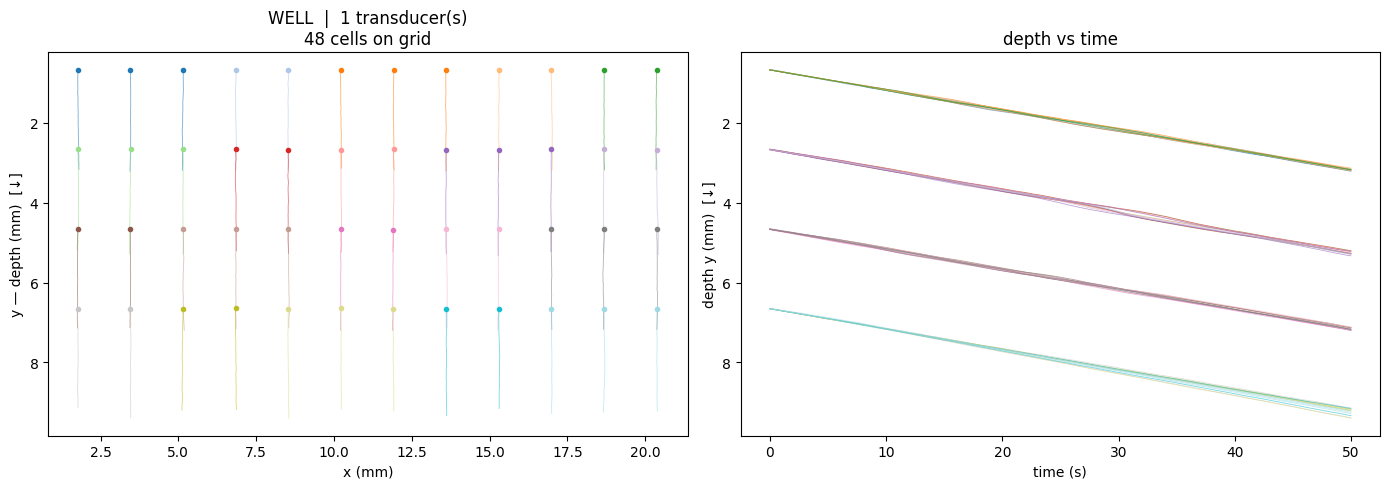

In [16]:
def plot_trajectories(sim_entry, ax_xy, ax_yt):
    """Plot x-y paths and y(t) depth traces for all cells in one simulation."""
    _, particle_indices, time_indices, xvals = \
        SFI.SFI_utils.load_trajectory_csv(sim_entry['trajectory_file'])

    n_cells = int(particle_indices.max()) + 1
    colors = plt.cm.tab20(np.linspace(0, 1, n_cells))
    dt_val = sim_entry['dt']

    for pid in range(n_cells):
        mask = particle_indices == pid
        x_mm = xvals[mask, 0] * 1e3
        y_mm = xvals[mask, 1] * 1e3
        t    = time_indices[mask] * dt_val
        col  = colors[pid % len(colors)]
        ax_xy.plot(x_mm, y_mm, lw=0.6, alpha=0.6, color=col)
        ax_xy.plot(x_mm[0], y_mm[0], 'o', ms=3, color=col)
        ax_yt.plot(t, y_mm, lw=0.6, alpha=0.6, color=col)

    ax_xy.set_xlabel('x (mm)')
    ax_xy.set_ylabel('y — depth (mm)  [↓]')
    ax_xy.invert_yaxis()
    ax_xy.set_title(f"{sim_entry['geometry'].upper()}  |  {sim_entry['n_transducers']} transducer(s)\n"
                    f"{n_cells} cells on grid")

    ax_yt.set_xlabel('time (s)')
    ax_yt.set_ylabel('depth y (mm)  [↓]')
    ax_yt.invert_yaxis()
    ax_yt.set_title('depth vs time')


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_trajectories(sim_entry, axes[0], axes[1])
plt.tight_layout()
plt.savefig('trajectoryData/traj_viz_oli_sim0000.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. OLI Force Inference

The overdamped SFI basis is **position-only** — there are no velocity terms. We use:

- **Polynomial terms** (order 5 in 2D → 21 monomials): capture the smooth beam envelope and gravity-like drift.
- **Fourier terms** at the acoustic radiation-force spatial frequencies: capture the sub-mm fringe structure that polynomials cannot represent efficiently.

Total basis size: 21 spatial monomials + 4 Fourier terms = **25 functions**.

### Why normalise?

Position coordinates span ~1 cm; the acoustic fringe scale is ~0.75 mm. Normalising positions to unit variance centres the polynomial expansion and ensures the regression is numerically stable.

In [17]:
# ── Diffusion estimation ─────────────────────────────────────────────────────
# For the overdamped model D = kT/γ is the (position-integrated) diffusion.
# 'MSD' is the standard mean-squared-displacement estimator. Use 'Vestergaard'
# or 'WeakNoise' if measurement noise is significant (requires dX_minus).
S = SFI.OverdampedLangevinInference(data)
S.compute_diffusion_constant(method='MSD')
print(f"Inferred diffusion D:\n{np.array(S.diffusion_average)}")
print(f"\nTrue D: {sim_entry['diffusion']:.2e} m²/s  (overdamped scalar D = kT/γ)")

# ── Coordinate normalisation ─────────────────────────────────────────────────
# Position (~1e-2 m) — normalise to unit variance for stable regression.
x_mean_np = np.mean(np.array(data.X), axis=(0, 1))   # (2,)  domain centroid [m]
x_std_np  = np.std (np.array(data.X), axis=(0, 1))   # (2,)  positional spread [m]

x_mean_j = jnp.array(x_mean_np)
x_std_j  = jnp.array(x_std_np)

print(f"\nNormalisation scales:")
print(f"  x_mean = {x_mean_np*1e3} mm")
print(f"  x_std  = {x_std_np*1e3} mm")

Measurement noise trace: -2.872806159626151e-13.
Inferred diffusion D:
[[8.9241440e-13 1.8328627e-14]
 [1.8328627e-14 1.3966323e-11]]

True D: 1.00e-08 m²/s  (overdamped scalar D = kT/γ)

Normalisation scales:
  x_mean = [11.0703745  4.932248 ] mm
  x_std  = [5.8351593 2.3570604] mm


In [18]:
# ── Force basis: order-5 position polynomial + Fourier acoustic terms ─────────
# 21 spatial monomials (order 5 in 2D)  +  4 Fourier terms  = 25 total.
# No velocity terms — the overdamped model has no inertia.
from jax import jit as _jit

ACOUSTIC_SPEED_MPS = 1500.0
ACOUSTIC_FREQ_HZ   = float(sim_entry.get('frequency_hz', 1e6))
_lambda_m = ACOUSTIC_SPEED_MPS / ACOUSTIC_FREQ_HZ   # 1.5 mm
_k_rf     = jnp.array(2 * np.pi / (_lambda_m / 2))  # radiation-force fringe period (λ/2)
_k_ac     = jnp.array(2 * np.pi / _lambda_m)        # acoustic wavelength

# Build position-only polynomial basis (order 5 in 2D → 21 monomials)
poly_fn, poly_names = SFI.OLI_bases.polynomial_basis(data.d, order=5)

@_jit
def norm_scalar_basis(x):
    """Order-5 position polynomial + Fourier acoustic fringe terms (position only)."""
    x_n = (x - x_mean_j) / x_std_j
    y   = x[1]   # depth [m] — physical coordinate for Fourier terms
    fourier = jnp.array([
        jnp.sin(_k_rf * y), jnp.cos(_k_rf * y),   # λ/2 fringes (radiation force period)
        jnp.sin(_k_ac * y), jnp.cos(_k_ac * y),   # λ-scale variation
    ])
    return jnp.concatenate([poly_fn(x_n), fourier])

# Generate names for all basis functions
fourier_names = ['sin(k_rf·y)', 'cos(k_rf·y)', 'sin(k_ac·y)', 'cos(k_ac·y)']
basis_names_scalar = poly_names + fourier_names

# Wrap scalar basis into SFI-compatible (im,mask→iam) form with auto-diff gradient
(force_b, force_grad_b), names = SFI.OLI_bases.basis_selector(
    {'type': 'custom_scalar', 'functions': norm_scalar_basis},
    data.d, output='vector'
)

# ── OLI linear force inference ─────────────────────────────────────────────
# G_mode='trapeze': trapezoidal correction (Amiri et al. PRR 2024), more robust
#   to measurement noise than the rectangle rule used in the 2020 PRX.
# M_mode='auto': automatically select Ito or Stratonovich based on noise level.
S.infer_force_linear(
    basis_linear          = force_b,
    basis_linear_gradient = force_grad_b,
    M_mode                = 'auto',
    G_mode                = 'trapeze',
    basis_names           = names,
)
S.compute_force_error()
S.print_report()

Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -2.872806159626151e-13). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[8.9241440e-13 1.8328627e-14]
 [1.8328627e-14 1.3966323e-11]]
Measurement noise tensor:
 [[-1.28998756e-14 -3.48021062e-16]
 [-3.48021009e-16 -2.74380751e-13]]
Force estimated information: 111634.9140625
Force: estimated normalized mean squared error (sampling only): 0.0008957759710028768
Force model:
 +8.752e-08 (±1.056e-07) b₀·e₀ -4.493e-07 (±2.139e-07) b₁·e₀ +1.671e-07 (±1.967e-07) b₂·e₀ -3.612e-07 (±1.68e-07) b₃·e₀ -1.038e-07 (±1.289e-07) b₄·e₀ +2.015e-07 (±1.464e-07) b₅·e₀ +5.955e-07 (±2.596e-07) b₆·e₀ -1.829e-07 (±1.87e-07) b₇·e₀ +1.636e-07 (±1.7e-07) b₈·e₀ -3.217e-08 (±2.068e-07) b₉·e₀ +1.594e-07 (±6.174e-08) b₁₀·e₀ +8.483e-08 (±5.124e-08) b₁₁·e₀ -6.262e-08 (±4.638e-08) b₁₂·e₀ -2.821e-08 (±4.317e-08) b₁₃·e₀ -4.668e-08 (±4.724e-08) b₁₄·e₀ -1.264e-07 (±7.772e-08) b₁₅·e₀ +4.524e-08 (±6.188e-08

## 4. Inferred force coefficients

In the overdamped model the inferred quantity is $F(x) = F_{\rm acoustic}(x)/\gamma$ (units m/s). There is no velocity term and no direct $\gamma$ estimate — damping is absorbed into the diffusion constant $D = k_BT/\gamma$.

In [21]:
print("Inferred force coefficients (overdamped):")
print(f"{'Basis function':25s}  {'Coefficient':>14s}  {'Std error':>12s}")
print("-" * 55)
coeffs_arr = np.array(S.force_coefficients)
stderr_arr = np.array(S.force_coefficients_stderr) if hasattr(S, 'force_coefficients_stderr') else np.zeros_like(coeffs_arr)
for name, c, se in zip(names, coeffs_arr, stderr_arr):
    print(f"{name:25s}  {c:14.4e}  {se:12.4e}")

# Diffusion ratio D_inferred / D_true gives an estimate of how well
# the overall mobility scale was recovered.
D_inferred = float(np.mean(np.diag(np.array(S.diffusion_average))))
D_true     = sim_entry['diffusion']
print(f"\nDiffusion recovery:  D_inferred = {D_inferred:.3e}   D_true = {D_true:.3e}   "
      f"ratio = {D_inferred/D_true:.3f}")

Inferred force coefficients (overdamped):
Basis function                Coefficient     Std error
-------------------------------------------------------
b₀·e₀                          8.7518e-08    1.0559e-07
b₁·e₀                         -4.4934e-07    2.1389e-07
b₂·e₀                          1.6713e-07    1.9669e-07
b₃·e₀                         -3.6124e-07    1.6804e-07
b₄·e₀                         -1.0381e-07    1.2894e-07
b₅·e₀                          2.0153e-07    1.4644e-07
b₆·e₀                          5.9549e-07    2.5963e-07
b₇·e₀                         -1.8287e-07    1.8700e-07
b₈·e₀                          1.6356e-07    1.7004e-07
b₉·e₀                         -3.2172e-08    2.0675e-07
b₁₀·e₀                         1.5940e-07    6.1743e-08
b₁₁·e₀                         8.4825e-08    5.1236e-08
b₁₂·e₀                        -6.2623e-08    4.6376e-08
b₁₃·e₀                        -2.8207e-08    4.3174e-08
b₁₄·e₀                        -4.6685e-08    4.7235e-08
b₁₅·e₀

## 5. Validate: compare inferred force map to ground-truth k-Wave field

The OLI inferred force $F(x)$ has units m/s (drift velocity). To compare with the k-Wave radiation force density (m/s²) we need the effective drag coefficient $\gamma = k_BT / D$. However, because $\gamma$ is absorbed into $D$, and the k-Wave field already represents the raw body-force acceleration, we compare the **spatial pattern** via Pearson $r$ rather than the absolute magnitude.

In [22]:
PML_SIZE           = 20
TARGET_PRESSURE_PA = 160e3
FORCE_SCALE        = 1.0 / 1050.0
PRESSURE_SCALE     = TARGET_PRESSURE_PA ** 2

def load_ground_truth(acoustic_h5, force_boost=1.0):
    """
    Return the ground-truth downward radiation force acceleration field [m/s²].
    """
    with h5py.File(acoustic_h5, 'r') as f:
        rf = f['radiation_force_dens'][:]
        Nx = int(f.attrs['Nx']); Ny = int(f.attrs['Ny']); dx = float(f.attrs['dx_m'])
    rf_int = rf[PML_SIZE:Nx-PML_SIZE, PML_SIZE:Ny-PML_SIZE]
    iNx, iNy = rf_int.shape
    x_m = np.arange(iNx) * dx
    y_m = np.arange(iNy) * dx
    Fy  = rf_int * PRESSURE_SCALE * FORCE_SCALE * force_boost
    return Fy, x_m, y_m


Fy_gt, x_m_gt, y_m_gt = load_ground_truth(
    sim_entry['acoustic_field_file'],
    force_boost=sim_entry.get('force_boost', 1.0)
)

# Evaluate OLI inferred force on the ground-truth grid
XX, YY = np.meshgrid(x_m_gt, y_m_gt, indexing='ij')   # (iNx, iNy)
Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)    # (N, 2)

# OLI force: F = einsum('a, iam -> im', coeffs, basis(x, mask))
coeffs = jnp.array(S.force_coefficients)   # shape (n_basis * dim,) for vector output

def eval_force(x):
    """Evaluate overdamped inferred force at one position x of shape (2,)."""
    basis = force_b(x[None], None)   # (1, n_basis, dim)
    return jnp.einsum('a,iam->im', coeffs, basis)[0]   # (dim,)

F_inferred_flat = np.array(vmap(eval_force)(
    jnp.array(Xeval, dtype=jnp.float32)
))   # (N, 2)

Fy_inferred = F_inferred_flat[:, 1].reshape(XX.shape)   # y-component (depth direction)

print(f"Ground-truth Fy range (m/s²): {Fy_gt.min():.3e} .. {Fy_gt.max():.3e}")
print(f"Inferred Fy range (m/s, drift): {Fy_inferred.min():.3e} .. {Fy_inferred.max():.3e}")

Ground-truth Fy range (m/s²): 1.728e-03 .. 4.392e-03
Inferred Fy range (m/s, drift): 4.400e-05 .. 6.145e-05


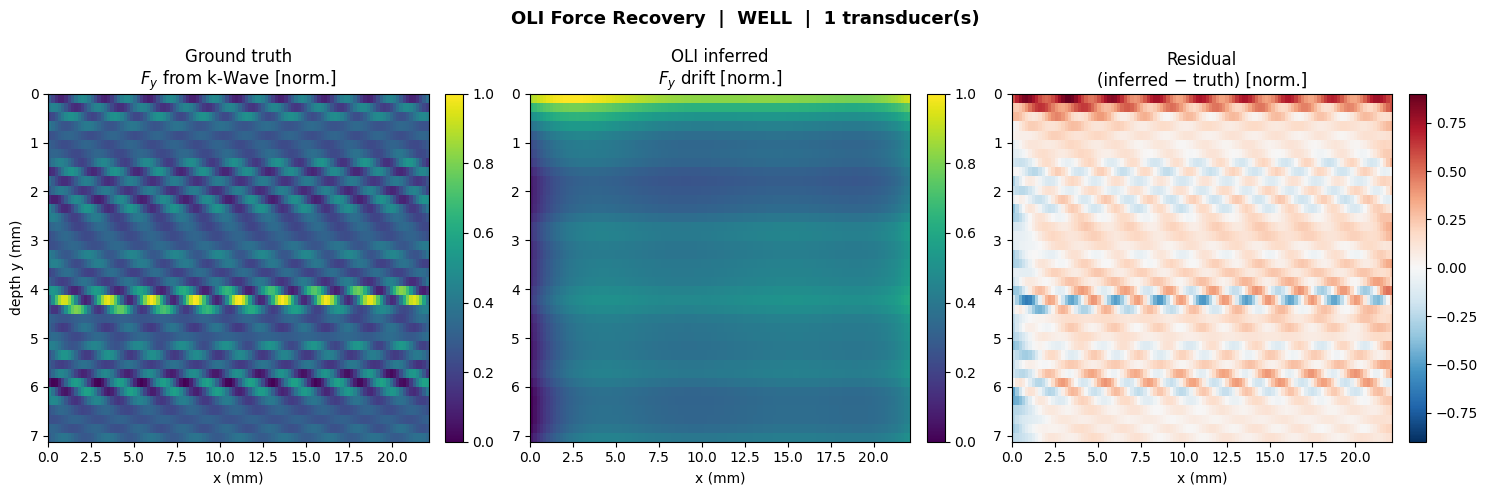

Pearson r (full resolution): 0.052
Pearson r (2 mm smoothed):   -0.469
RMSE (normalised fields):    0.1913


In [23]:
# ── Normalise inferred field to ground-truth scale for visual comparison ──────
# OLI inferred F has units m/s (drift); ground truth has units m/s².
# We normalise both to [0, 1] for spatial-pattern comparison.
def norm01(arr):
    lo, hi = arr.min(), arr.max()
    return (arr - lo) / (hi - lo + 1e-30)

Fy_gt_n  = norm01(Fy_gt)
Fy_inf_n = norm01(Fy_inferred)

extent = [x_m_gt[0]*1e3, x_m_gt[-1]*1e3, y_m_gt[-1]*1e3, y_m_gt[0]*1e3]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"OLI Force Recovery  |  {sim_entry['geometry'].upper()}  |  {sim_entry['n_transducers']} transducer(s)",
    fontsize=13, fontweight='bold'
)

# Ground truth (normalised)
ax = axes[0]
im = ax.imshow(Fy_gt_n.T, origin='upper', aspect='auto', extent=extent,
               cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Ground truth\n$F_y$ from k-Wave [norm.]')
ax.set_xlabel('x (mm)'); ax.set_ylabel('depth y (mm)')

# OLI inferred (normalised)
ax = axes[1]
im = ax.imshow(Fy_inf_n.T, origin='upper', aspect='auto', extent=extent,
               cmap='viridis', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('OLI inferred\n$F_y$ drift [norm.]')
ax.set_xlabel('x (mm)')

# Residual of normalised fields
resid = Fy_inf_n - Fy_gt_n
ax = axes[2]
lim = np.abs(resid).max()
im = ax.imshow(resid.T, origin='upper', aspect='auto', extent=extent,
               cmap='RdBu_r', vmin=-lim, vmax=lim)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Residual\n(inferred − truth) [norm.]')
ax.set_xlabel('x (mm)')

plt.tight_layout()
plt.savefig(f'trajectoryData/oli_recovery_sim{SIM_IDX:04d}.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Correlation metrics ───────────────────────────────────────────────────────
dx_m = x_m_gt[1] - x_m_gt[0]
sigma_2mm = 2e-3 / dx_m
gt_sm  = gaussian_filter(Fy_gt,  sigma=sigma_2mm)
inf_sm = gaussian_filter(Fy_inferred, sigma=sigma_2mm)
r_full = np.corrcoef(Fy_gt.ravel(), Fy_inferred.ravel())[0, 1]
r_2mm  = np.corrcoef(gt_sm.ravel(), inf_sm.ravel())[0, 1]
rmse   = np.sqrt(np.mean((Fy_inf_n - Fy_gt_n)**2))
print(f"Pearson r (full resolution): {r_full:.3f}")
print(f"Pearson r (2 mm smoothed):   {r_2mm:.3f}")
print(f"RMSE (normalised fields):    {rmse:.4f}")

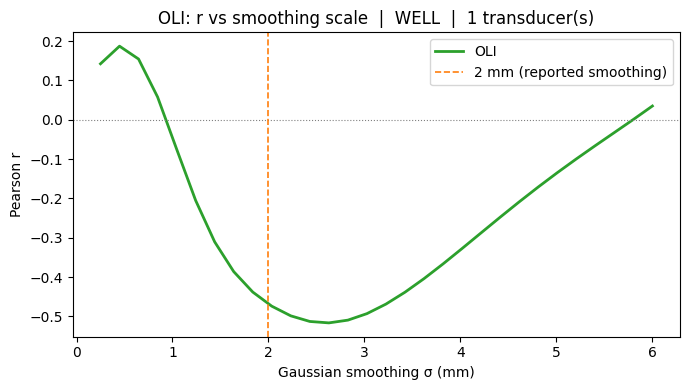

In [24]:
# ── Pearson r vs smoothing scale ──────────────────────────────────────────────
dx_m_gt = x_m_gt[1] - x_m_gt[0]
sigmas_mm = np.linspace(0.25, 6.0, 30)
rs_vs_sigma = []
for s_mm in sigmas_mm:
    sig_px = s_mm * 1e-3 / dx_m_gt
    gt_s  = gaussian_filter(Fy_gt,       sigma=sig_px)
    inf_s = gaussian_filter(Fy_inferred, sigma=sig_px)
    rs_vs_sigma.append(np.corrcoef(gt_s.ravel(), inf_s.ravel())[0, 1])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sigmas_mm, rs_vs_sigma, lw=2, color='C2', label='OLI')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axvline(2.0, color='C1', lw=1.2, ls='--', label='2 mm (reported smoothing)')
ax.set_xlabel('Gaussian smoothing σ (mm)')
ax.set_ylabel('Pearson r')
ax.set_title(f"OLI: r vs smoothing scale  |  {sim_entry['geometry'].upper()}  "
             f"|  {sim_entry['n_transducers']} transducer(s)")
ax.legend()
plt.tight_layout()
plt.savefig(f'trajectoryData/oli_r_vs_sigma_sim{SIM_IDX:04d}.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Compare multiple transducer configurations

Run OLI on all simulations and collect Pearson r for each.

In [25]:
def run_oli(sim_entry):
    """Full OLI pipeline for one simulation. Returns (r_full, r_2mm, rmse, D_inferred, S)."""
    data, dt = load_trajectories(sim_entry)

    S = SFI.OverdampedLangevinInference(data)
    S.compute_diffusion_constant(method='MSD')

    # Per-simulation normalisation (position scales)
    x_mean_j_ = jnp.array(np.mean(np.array(data.X), axis=(0, 1)))
    x_std_j_  = jnp.array(np.std (np.array(data.X), axis=(0, 1)))

    # Fourier wavenumbers at acoustic radiation force scales
    freq_hz_   = float(sim_entry.get('frequency_hz', 1e6))
    lambda_m_  = 1500.0 / freq_hz_
    k_rf_      = jnp.array(2 * np.pi / (lambda_m_ / 2))
    k_ac_      = jnp.array(2 * np.pi / lambda_m_)

    poly_fn_, _ = SFI.OLI_bases.polynomial_basis(data.d, order=5)

    @jit
    def _norm_basis(x):
        x_n = (x - x_mean_j_) / x_std_j_
        y   = x[1]
        fourier = jnp.array([
            jnp.sin(k_rf_ * y), jnp.cos(k_rf_ * y),
            jnp.sin(k_ac_ * y), jnp.cos(k_ac_ * y),
        ])
        return jnp.concatenate([poly_fn_(x_n), fourier])

    (force_b_, force_grad_b_), names_ = SFI.OLI_bases.basis_selector(
        {'type': 'custom_scalar', 'functions': _norm_basis},
        data.d, output='vector'
    )
    S.infer_force_linear(
        basis_linear=force_b_, basis_linear_gradient=force_grad_b_,
        M_mode='auto', G_mode='trapeze',
        basis_names=names_
    )
    S.compute_force_error()

    D_inferred = float(np.mean(np.diag(np.array(S.diffusion_average))))

    # Ground truth
    Fy_gt, x_m, y_m = load_ground_truth(
        sim_entry['acoustic_field_file'],
        force_boost=sim_entry.get('force_boost', 1.0)
    )
    XX, YY = np.meshgrid(x_m, y_m, indexing='ij')
    Xeval  = np.stack([XX.ravel(), YY.ravel()], axis=-1)
    c_     = jnp.array(S.force_coefficients)

    def ef_(x):
        return jnp.einsum('a,iam->im', c_, force_b_(x[None], None))[0]

    F_inf = np.array(vmap(ef_)(
        jnp.array(Xeval, dtype=jnp.float32)
    ))
    Fy_inf = F_inf[:, 1].reshape(XX.shape)

    dx_m_     = x_m[1] - x_m[0]
    sigma_2mm = 2e-3 / dx_m_
    gt_sm     = gaussian_filter(Fy_gt,  sigma=sigma_2mm)
    inf_sm    = gaussian_filter(Fy_inf, sigma=sigma_2mm)

    r_full = np.corrcoef(Fy_gt.ravel(), Fy_inf.ravel())[0, 1]
    r_2mm  = np.corrcoef(gt_sm.ravel(), inf_sm.ravel())[0, 1]

    def norm01_(arr):
        lo, hi = arr.min(), arr.max()
        return (arr - lo) / (hi - lo + 1e-30)

    rmse = float(np.sqrt(np.mean((norm01_(Fy_inf) - norm01_(Fy_gt))**2)))
    return r_full, r_2mm, rmse, D_inferred, S


# Run on all simulations
results = []
for entry in traj_meta:
    print(f"Sim {entry['sim_index']:04d}  {entry['geometry']:5s}  {entry['n_transducers']}tx  ",
          end='', flush=True)
    r_full, r_2mm, rmse, D_inf, _ = run_oli(entry)
    results.append({
        'sim_index':     entry['sim_index'],
        'geometry':      entry['geometry'],
        'n_transducers': entry['n_transducers'],
        'pearson_r':     float(r_full),
        'pearson_r_2mm': float(r_2mm),
        'rmse':          float(rmse),
        'D_inferred':    float(D_inf),
        'D_true':        float(entry['diffusion']),
    })
    print(f"r={r_full:.3f}  r_2mm={r_2mm:.3f}  RMSE={rmse:.4f}  "
          f"D={D_inf:.2e} (true {entry['diffusion']:.2e})")

Sim 0000  well   1tx  Measurement noise trace: -2.872806159626151e-13.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -2.872806159626151e-13). 
r=0.052  r_2mm=-0.469  RMSE=0.1913  D=7.43e-12 (true 1.00e-08)
Sim 0001  well   2tx  Measurement noise trace: -5.782047475359764e-13.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -5.782047475359764e-13). 
r=0.099  r_2mm=0.609  RMSE=0.2818  D=1.47e-11 (true 1.00e-08)
Sim 0002  well   2tx  Measurement noise trace: -2.8753986903084713e-14.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -2.8753986903084713e-14). 
r=-0.011  r_2mm=-0.279  RMSE=0.3093  D=9.66e-13 (true 1.00e-08)
Sim 0003  well   2tx  Measurement noise trace: -5.757832361938386e-13.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -5.757832361938386e-13). 
r=0.102  r_2mm=0.715  RMSE=0.2958  D=1.46e-11

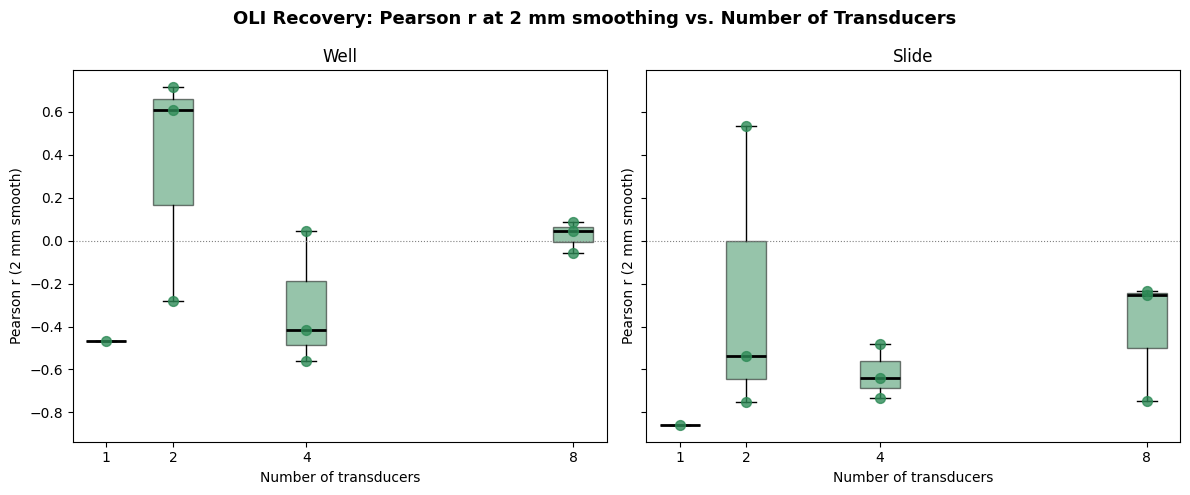

Diffusion recovery across all simulations:
  mean inferred D = 1.020e-10 m²/s
  true D          = 1.000e-08 m²/s
  mean abs error  = 9.898e-09 m²/s  (99.0%)
Results saved to trajectoryData/oli_results.json


In [26]:
# Summary: Pearson r (2 mm smoothed) vs n_transducers — box plots by geometry
import pandas as pd

df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle('OLI Recovery: Pearson r at 2 mm smoothing vs. Number of Transducers',
             fontsize=13, fontweight='bold')

for ax, geo in zip(axes, ['well', 'slide']):
    geo_df    = df[df['geometry'] == geo]
    ntx_vals  = sorted(geo_df['n_transducers'].unique())
    data_box  = [geo_df.loc[geo_df['n_transducers'] == ntx, 'pearson_r_2mm'].values
                 for ntx in ntx_vals]
    bp = ax.boxplot(data_box, positions=ntx_vals, widths=0.6, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch in bp['boxes']:
        patch.set_facecolor('seagreen')
        patch.set_alpha(0.5)
    for ntx, vals in zip(ntx_vals, data_box):
        ax.scatter([ntx] * len(vals), vals, color='seagreen', s=50, zorder=3, alpha=0.8)
    ax.axhline(0, color='gray', lw=0.8, ls=':')
    ax.set_xlabel('Number of transducers')
    ax.set_ylabel('Pearson r (2 mm smooth)')
    ax.set_title(geo.capitalize())
    ax.set_xticks(ntx_vals)

plt.tight_layout()
plt.savefig('trajectoryData/oli_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Diffusion recovery summary ────────────────────────────────────────────────
print("Diffusion recovery across all simulations:")
print(f"  mean inferred D = {df['D_inferred'].mean():.3e} m²/s")
print(f"  true D          = {df['D_true'].iloc[0]:.3e} m²/s")
print(f"  mean abs error  = {(df['D_inferred'] - df['D_true']).abs().mean():.3e} m²/s  "
      f"({100*(df['D_inferred'] - df['D_true']).abs().mean()/df['D_true'].iloc[0]:.1f}%)")

import json as _json
_json.dump(results, open('trajectoryData/oli_results.json', 'w'), indent=2)
print('Results saved to trajectoryData/oli_results.json')

## 7. Summary

This notebook demonstrated the overdamped Langevin inference pipeline for the Bespoke Ultrasound project:

| Step | Tool | Output |
|------|------|--------|
| Acoustic simulation | `kwaveTrainingDataGenerator.py` | Radiation force HDF5 |
| Trajectory simulation | `simulateTrajectories.py` | Multi-particle CSVs |
| OLI inference | `SFI.OverdampedLangevinInference` | Force coefficients |
| Validation | Pearson r vs k-Wave ground truth | `oli_results.json` |

### Key differences vs ULI

- **No velocity basis terms** — the overdamped model only needs position.
- **No $\gamma$ recovery** — damping is implicit in $D = k_BT/\gamma$.
- **Simpler trajectory loading** — no `compute_dXplus` required.
- The inferred $F(x)$ has units m/s (drift), not m/s² (acceleration). Spatial patterns are compared with the k-Wave field after normalisation.

### When to prefer OLI vs ULI

- **OLI** is appropriate when $\Delta t \gg m/\gamma$ (inertia fully relaxed between steps), fewer parameters, more robust at low SNR.
- **ULI** is appropriate when inertial effects are detectable and allows explicit $\gamma$ recovery from the velocity damping coefficient.